# 06 · Supervised ML

**Split:** official train/test files - there are no timestamps for a time-based split, and the files are not shuffled together, so no shuffle leakage. Preprocessing is fit on train only.

**Excluded features:** ids (row order follows class blocks), label / attack_cat, split, cleaning flags, TCP sequence numbers.

**Imbalance:** `class_weight='balanced'`.

Training all six models takes ~15-20 minutes, so by default this notebook **loads the results saved by the pipeline** (`python src/run_pipeline.py --only 7`). Set `RETRAIN = True` to retrain here.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
SRC = Path.cwd().parent / 'src' if (Path.cwd().parent / 'src').exists() else Path.cwd() / 'src'
sys.path.insert(0, str(SRC))
import pandas as pd, json
from IPython.display import Image, Markdown, display
from config import FIG_DIR, METRICS_DIR, REPORTS_DIR, EXPORT_DIR
pd.set_option('display.max_columns', 60, 'display.width', 200)
def show(name, width=900):
    display(Image(filename=str(FIG_DIR / f'{name}.png'), width=width))

In [2]:
RETRAIN = False
if RETRAIN:
    import supervised
    res = supervised.run()
else:
    res = json.loads((METRICS_DIR / 'supervised_results.json').read_text())
print('best binary:', res['best_binary'], '| best multiclass:', res['best_multiclass'])

best binary: LightGBM | best multiclass: RandomForest


## Binary: normal vs attack

In [3]:
pd.DataFrame(res['binary'])[['model','precision','recall_attack','f1','roc_auc','pr_auc','fpr','accuracy']]

,model,precision,recall_attack,f1,roc_auc,pr_auc,fpr,accuracy
0,LightGBM,0.8694,0.9729,0.9182,0.9854,0.9892,0.1791,0.9046
1,RandomForest,0.8458,0.9789,0.9075,0.9843,0.9883,0.2187,0.8901
2,LogisticRegression,0.8389,0.9389,0.8861,0.9663,0.9744,0.2209,0.8671


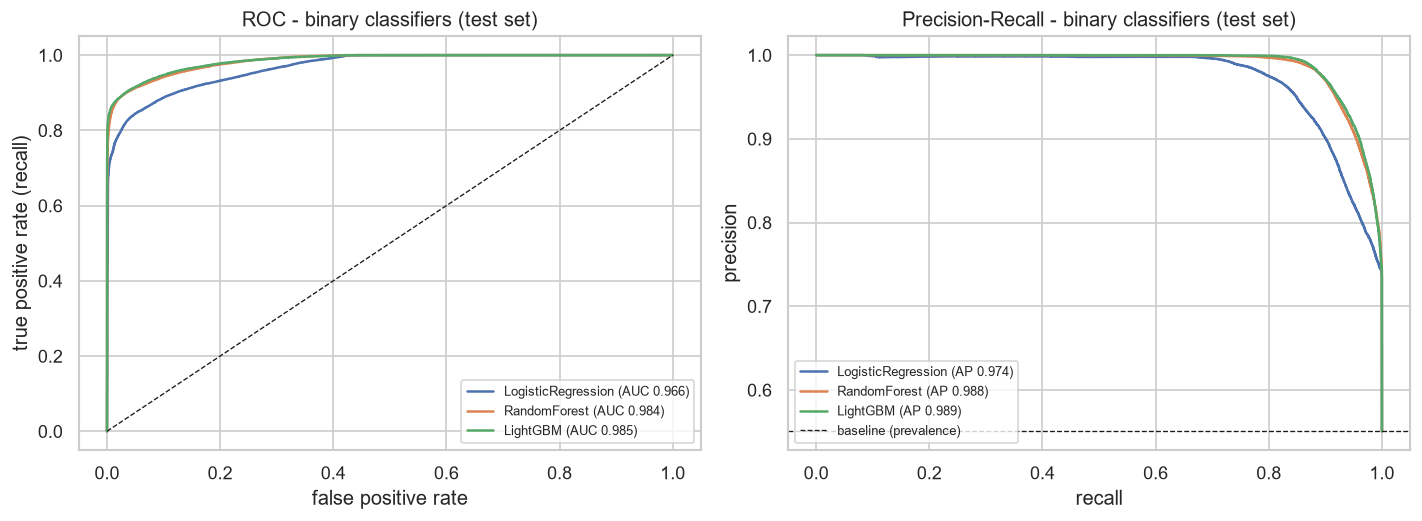

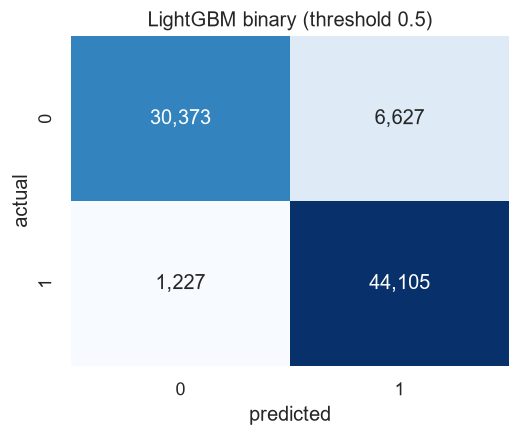

In [4]:
show('07_binary_roc_pr', 1000)
show('07_binary_confusion', 420)

In [5]:
pd.DataFrame(res['binary_detection_by_category'])

,attack_cat,flows,flagged_as_attack
0,Normal,37000,0.179108
1,Fuzzers,6062,0.819037
2,Analysis,677,0.967504
3,Shellcode,378,0.984127
4,Exploits,11132,0.992005
5,DoS,4089,0.998288
6,Reconnaissance,3496,0.998856
7,Generic,18871,0.999894
8,Backdoor,583,1.000000
9,Worms,44,1.000000


## Multiclass: attack category

In [6]:
display(pd.DataFrame(res['multiclass']))
display(pd.DataFrame(res['per_class']))

,model,macro_f1,weighted_f1,macro_recall,accuracy
0,RandomForest,0.5254,0.7694,0.5990,0.7260
1,LightGBM,0.5171,0.7517,0.6138,0.7010
2,LogisticRegression,0.3647,0.6885,0.5692,0.6235


,class,precision,recall,f1-score,support
0,Normal,0.9779,0.7006,0.8163,37000.0
1,Generic,0.9995,0.9660,0.9824,18871.0
2,Exploits,0.7705,0.6528,0.7068,11132.0
3,Fuzzers,0.2851,0.6532,0.3970,6062.0
4,DoS,0.3092,0.2304,0.2640,4089.0
5,Reconnaissance,0.9059,0.8181,0.8598,3496.0
6,Analysis,0.0128,0.0236,0.0166,677.0
7,Backdoor,0.0380,0.3654,0.0689,583.0
8,Shellcode,0.2844,0.8757,0.4293,378.0
9,Worms,0.7209,0.7045,0.7126,44.0


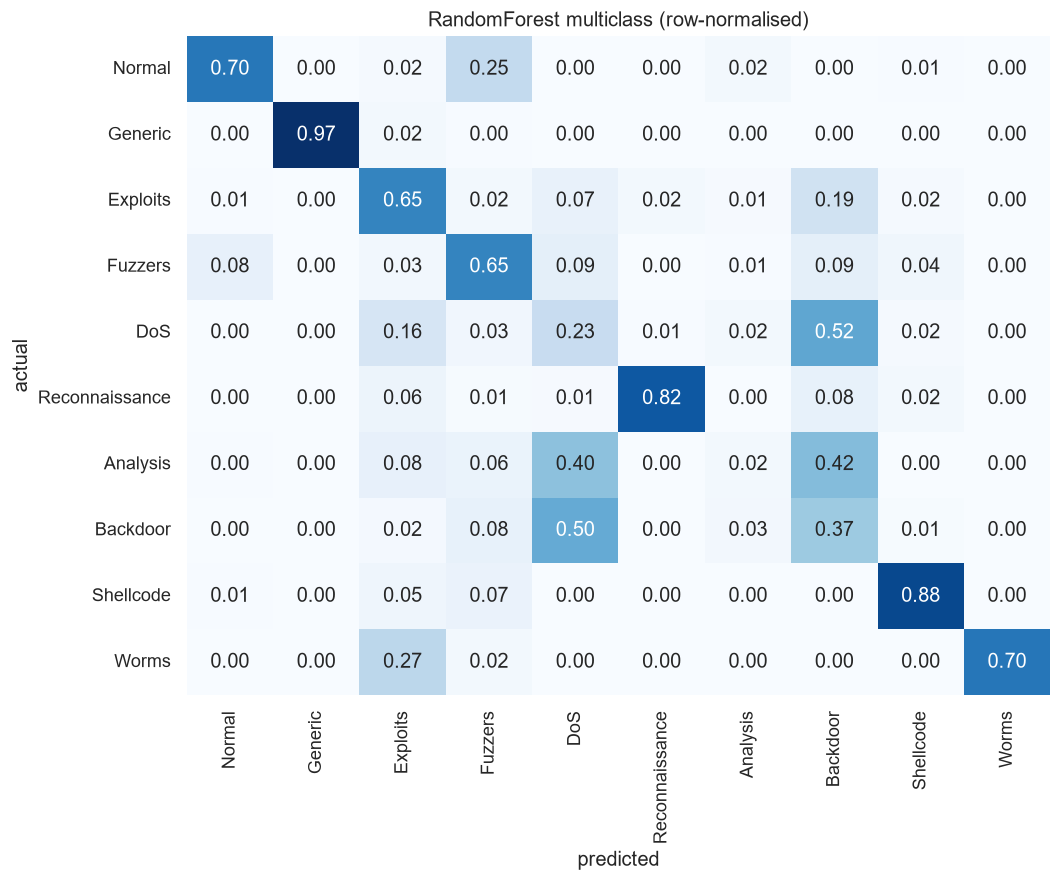

In [7]:
show('07_multiclass_confusion', 800)

## Explainability
Impurity / gain importance and SHAP (TreeExplainer on 2,000 random test flows).

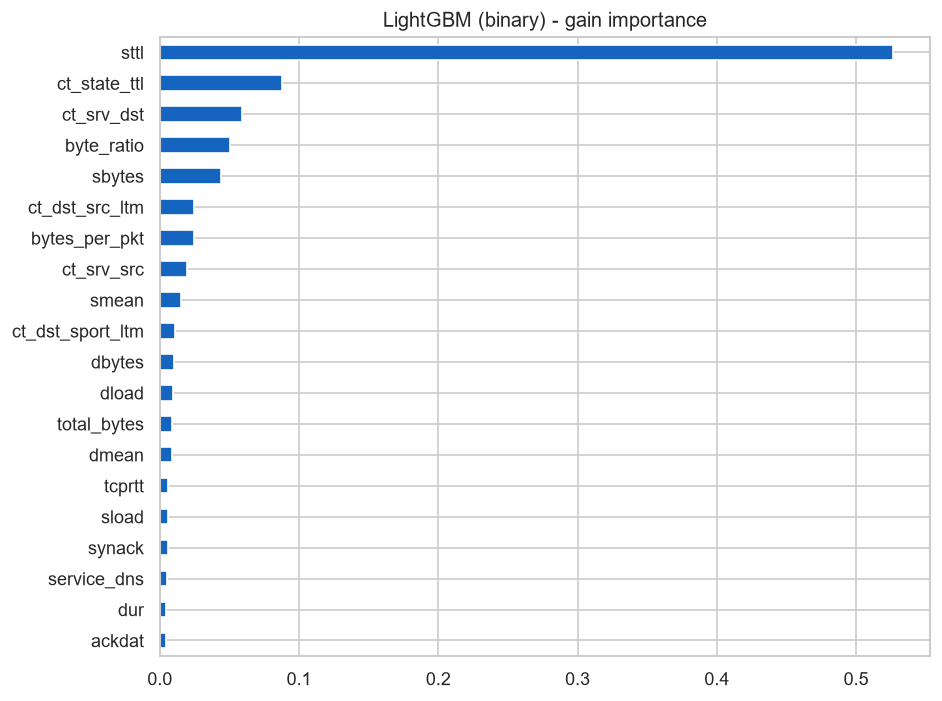

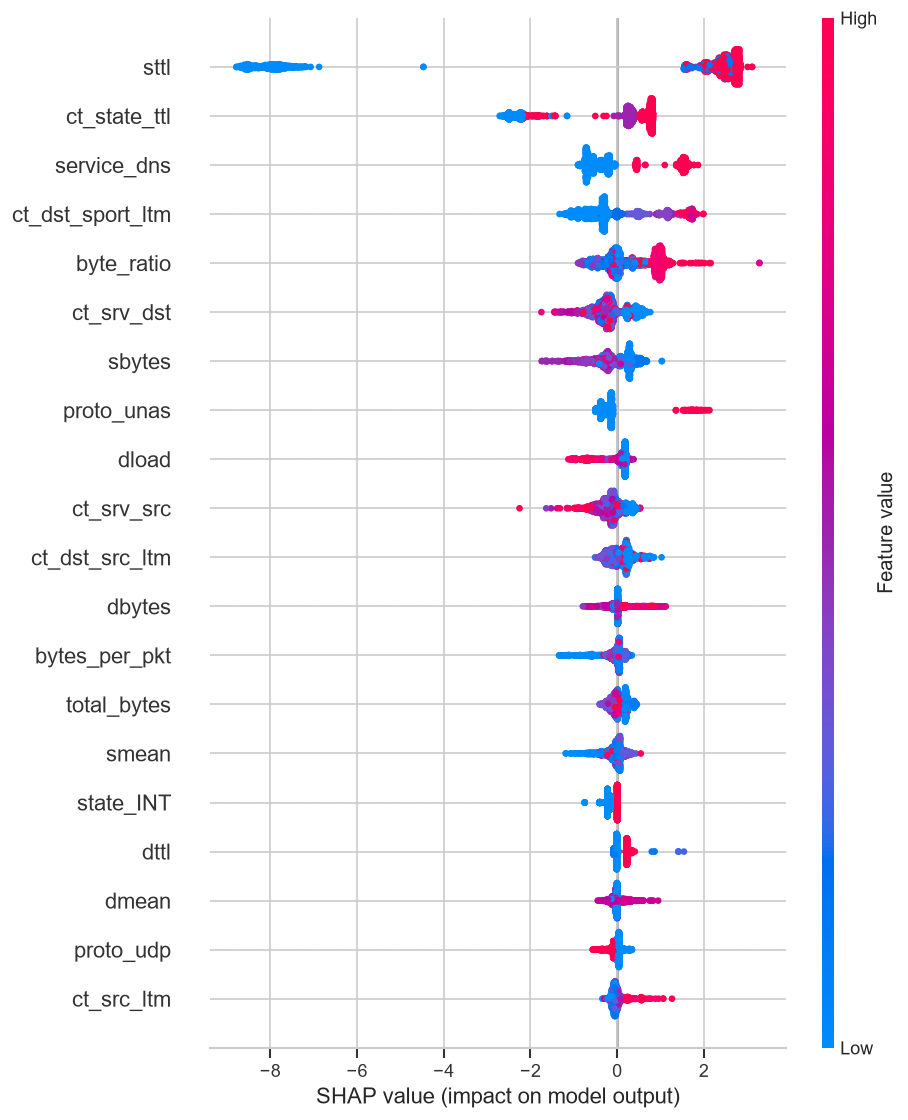

In [8]:
show('07_importance_lgbm', 600)
show('07_shap_summary', 700)